# Redes Neurais

## AE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_digits
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import MinMaxScaler

In [ ]:
digits = load_digits()
X = digits.data
# Normalizando os dados em escala 0-1
X = MinMaxScaler().fit_transform(X)

In [ ]:
X_train, X_test = X[:1500], X[1500:]

In [ ]:
# Arquitetura autoencoders
input_dim = X.shape[1]
encoding_dim = 32

In [ ]:
# Definição das camadas
input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation="relu")(input_layer)
decoder = Dense(input_dim, activation="sigmoid")(encoder)

In [ ]:
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer="adam", loss="mse")

In [ ]:
autoencoder.fit(X_train, X_train, epochs=20, batch_size=32)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0808
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0626
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0531
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0442
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0375
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0327
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0289
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0267
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0246
Epoch 10/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0229
Epoch 11/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0215
Epoch 12/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0204
Epoch 13/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0193
Epoch 14/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0180
Epoch 15/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0170
Epoch 16/20
47/47 ━

In [ ]:
#reconstrução
reconstructed = autoencoder.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


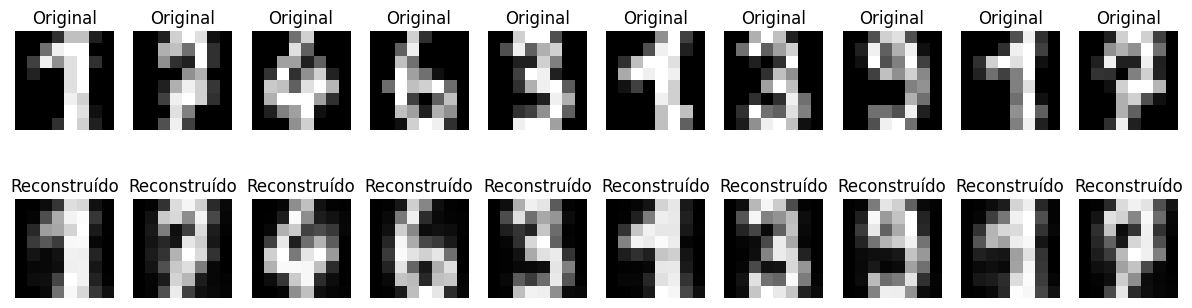

In [ ]:
# Visualização
n = 10
plt.figure(figsize=(15, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstruído
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].reshape(8, 8), cmap='gray')
    plt.title("Reconstruído")
    plt.axis('off')
plt.show()


## VAE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - kl_loss: 7.7195 - loss: 217.5475 - reconstruction_loss: 209.8280
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - kl_loss: 3.8118 - loss: 178.6280 - reconstruction_loss: 174.8162
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - kl_loss: 3.2918 - loss: 171.0025 - reconstruction_loss: 167.7107
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - kl_loss: 3.2137 - loss: 167.3850 - reconstruction_loss: 164.1713
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - kl_loss: 3.2302 - loss: 164.7486 - reconstruction_loss: 161.5184
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - kl_loss: 3.2437 - loss: 162.9682 - reconstruction_loss: 159.7245
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss: 3.2472 - loss: 161.6402 - reconstruction_loss: 158.3929
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 3.2681 - loss: 160.6143 - reconstruction_

In [ ]:
# Dados
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.
x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

latent_dim = 2

In [ ]:
# Encoder
encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation='relu')(x)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")


In [ ]:
#  Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(128, activation='relu')(latent_inputs)
x = layers.Dense(28 * 28, activation='sigmoid')(x)
decoder_outputs = layers.Reshape((28, 28, 1))(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")


In [ ]:
# Classe VAE com perda personalizada
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(data, reconstruction)
            ) * 28 * 28
            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

In [ ]:
# Compilar e treinar
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
vae.fit(x_train, epochs=10, batch_size=128)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


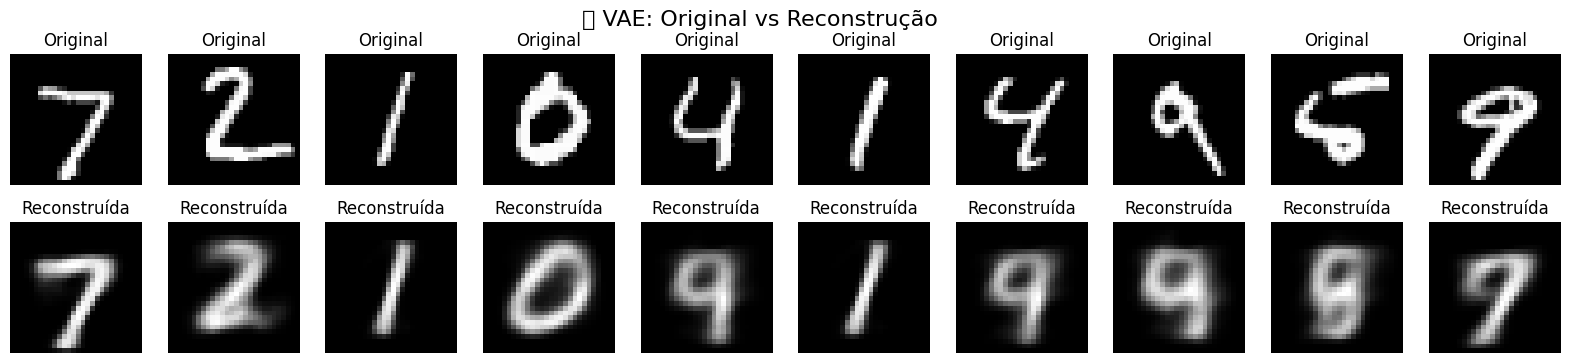

In [ ]:
# Visualização
reconstructed = vae.decoder.predict(encoder.predict(x_test[:10])[2])

plt.figure(figsize=(20, 4))
for i in range(10):
    # Original
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    # Reconstruída
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Reconstruída")

plt.suptitle("🧠 VAE: Original vs Reconstrução", fontsize=16)
plt.show()

## RBM

In [ ]:
from sklearn.neural_network import BernoulliRBM
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Dados
digits = datasets.load_digits()

# Normalizar os dados para faixa [0,1] (importante para a RBM)
X = MinMaxScaler().fit_transform(digits.data)
y = digits.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Criar pipeline com RBM + Regressão Logística
rbm = BernoulliRBM(n_components=64, learning_rate=0.06, n_iter=20, random_state=42)
logistic = LogisticRegression(max_iter=1000)
classifier = Pipeline(steps=[('rbm', rbm), ('logistic', logistic)])


In [ ]:
# Modelo
classifier.fit(X_train, y_train)

In [ ]:
#Métrica
acc = classifier.score(X_test, y_test)
print(f"🔹 Acurácia com RBM + Regressão Logística: {acc:.2%}")


🔹 Acurácia com RBM + Regressão Logística: 90.00%


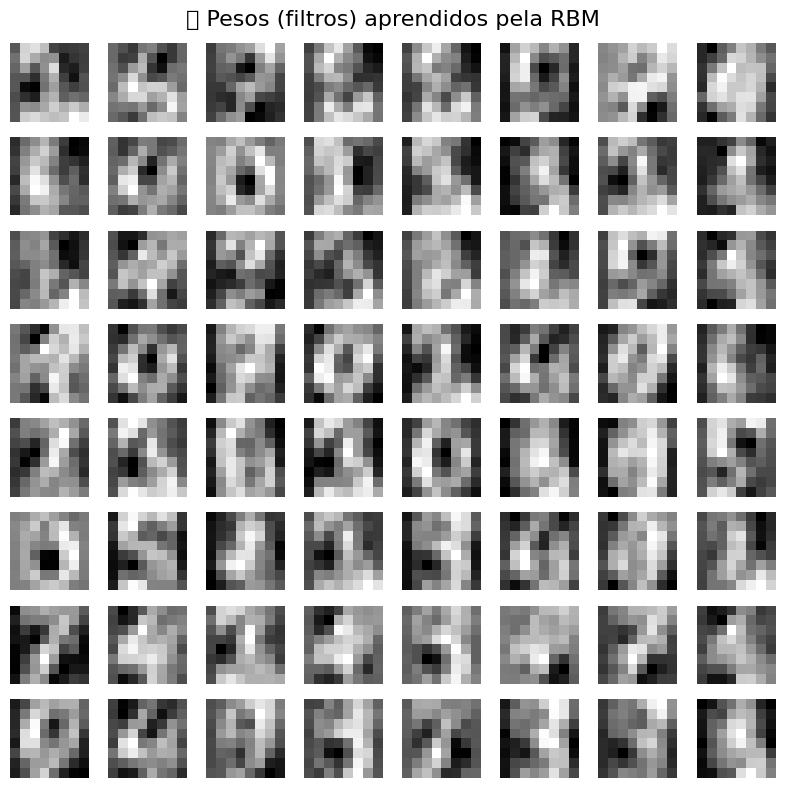

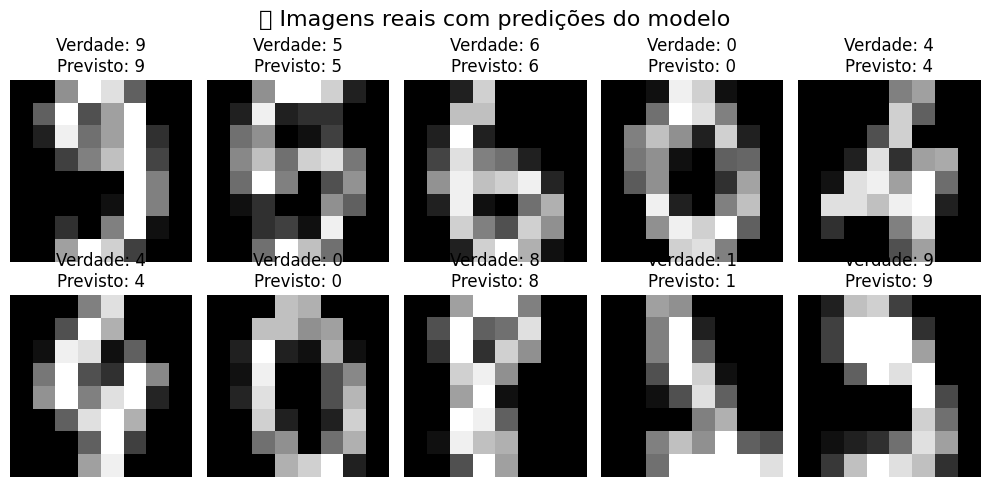

In [ ]:
# Visualização
plt.figure(figsize=(8, 8))
for i, comp in enumerate(rbm.components_[:64]):
    plt.subplot(8, 8, i + 1)
    plt.imshow(comp.reshape((8, 8)), cmap='gray')  # Reformatar cada vetor de 64 para imagem 8x8
    plt.axis('off')

plt.suptitle(' Pesos (filtros) aprendidos pela RBM', fontsize=16)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
for i in range(10):
    idx = np.random.randint(0, len(X_test))
    img = X_test[idx].reshape(8, 8)
    pred = classifier.predict([X_test[idx]])[0]
    true = y_test[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Verdade: {true}\nPrevisto: {pred}")
    plt.axis('off')

plt.suptitle("Imagens reais com predições do modelo", fontsize=16)
plt.tight_layout()
plt.show()